<a href="https://colab.research.google.com/github/rizwanmohammed1500/Occupational-Stress-Analysis/blob/main/IndpProjV4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loading Initial Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Initial Data
df = pd.read_csv('/content/Sleep_health_and_lifestyle_dataset.csv')
print("Occupation Counts:")
print(df['Occupation'].value_counts())
df.head()

Occupation Counts:
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Scientist                4
Software Engineer        4
Sales Representative     2
Manager                  1
Name: count, dtype: int64


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


#Data Cleaning

In [3]:
# 1. Standardize BMI
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

# 2. Convert Blood Pressure from text to numbers
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

# 3. Create a clean version
df_clean = df.drop(columns=['Person ID', 'Blood Pressure'])
print("Data Cleaned: Typos fixed and BP split into numeric values.")

Data Cleaned: Typos fixed and BP split into numeric values.


#Creating the Graphs

###Bar Graph: Occupation vs Stress Score

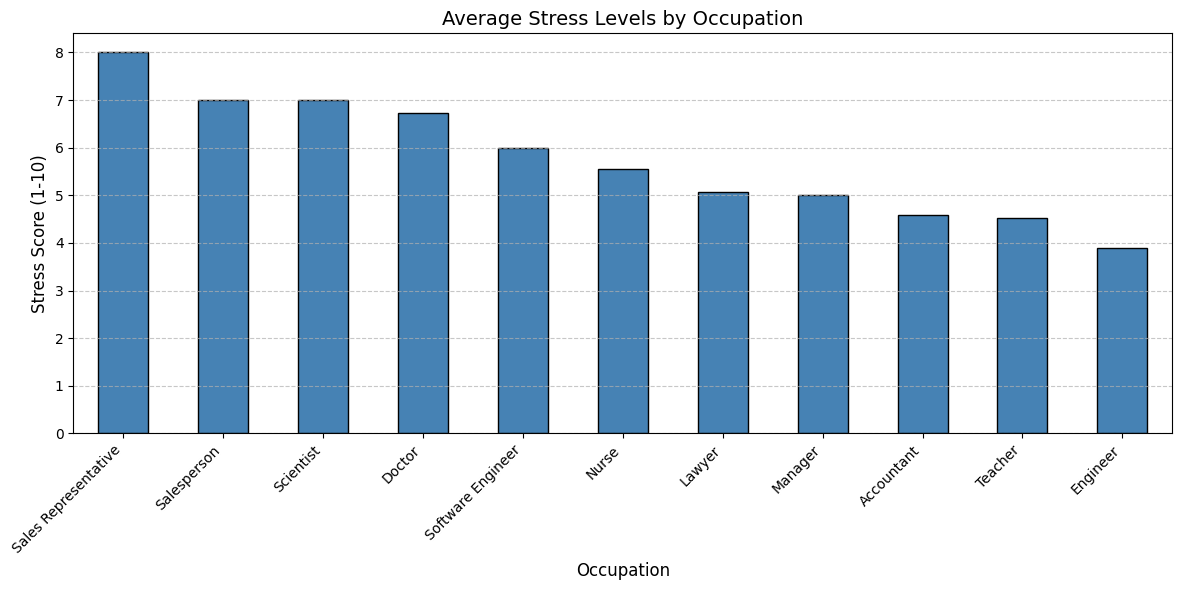

In [9]:
plt.figure(figsize=(12, 6))

# Group and sort
job_stress = df_clean.groupby('Occupation')['Stress Level'].mean().sort_values(ascending=False)

# Plotting
job_stress.plot(kind='bar', color='steelblue', edgecolor='black')

# Labeling
plt.title('Average Stress Levels by Occupation', fontsize=14)
plt.ylabel('Stress Score (1-10)', fontsize=12)
plt.xlabel('Occupation', fontsize=12)

# Rotating x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Box Plot: Stress Level vs Quality of Sleep

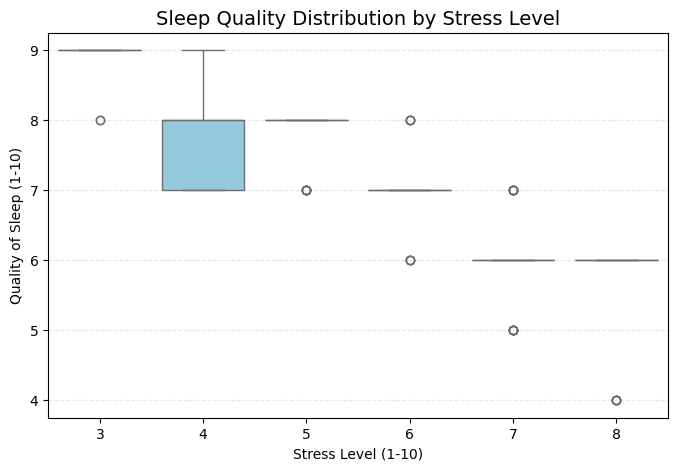

In [5]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_clean, x='Stress Level', y='Quality of Sleep', color='skyblue')

plt.title('Sleep Quality Distribution by Stress Level', fontsize=14)
plt.xlabel('Stress Level (1-10)')
plt.ylabel('Quality of Sleep (1-10)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()
